In [1]:
#%env JAX_PLATFORM=cpu
%env CUDA_VISIBLE_DEVICES=0
%env XLA_PYTHON_CLIENT_PREALLOCATE=false
%env JAX_ENABLE_X64=True

env: CUDA_VISIBLE_DEVICES=0
env: XLA_PYTHON_CLIENT_PREALLOCATE=false
env: JAX_ENABLE_X64=True


# Setup Simulator

In [2]:
from modules.systems import Cascade
from env import Simulator
from algorithms import p3o
from utils import *

In [ ]:
rngs = nnx.Rngs(0)
sys = Cascade(x_dim=2, u_dim=2, y_dim=1, action_range=(-0.05, 5.0))
env = Simulator(sys, t_aux_on=32, t_aux_off=96, rngs=rngs)
trainer = p3o.Trainer(env, max_cost=2.0, rngs=rngs)
nnx.display(trainer)
logger = trainer.train(epochs=1, episode_length=128)

100%|██████████| 1/1 [00:06<00:00,  6.15s/it, V=-3.65, Vc=5.64, cost=0.244, reward=-.0618]


# Null policy

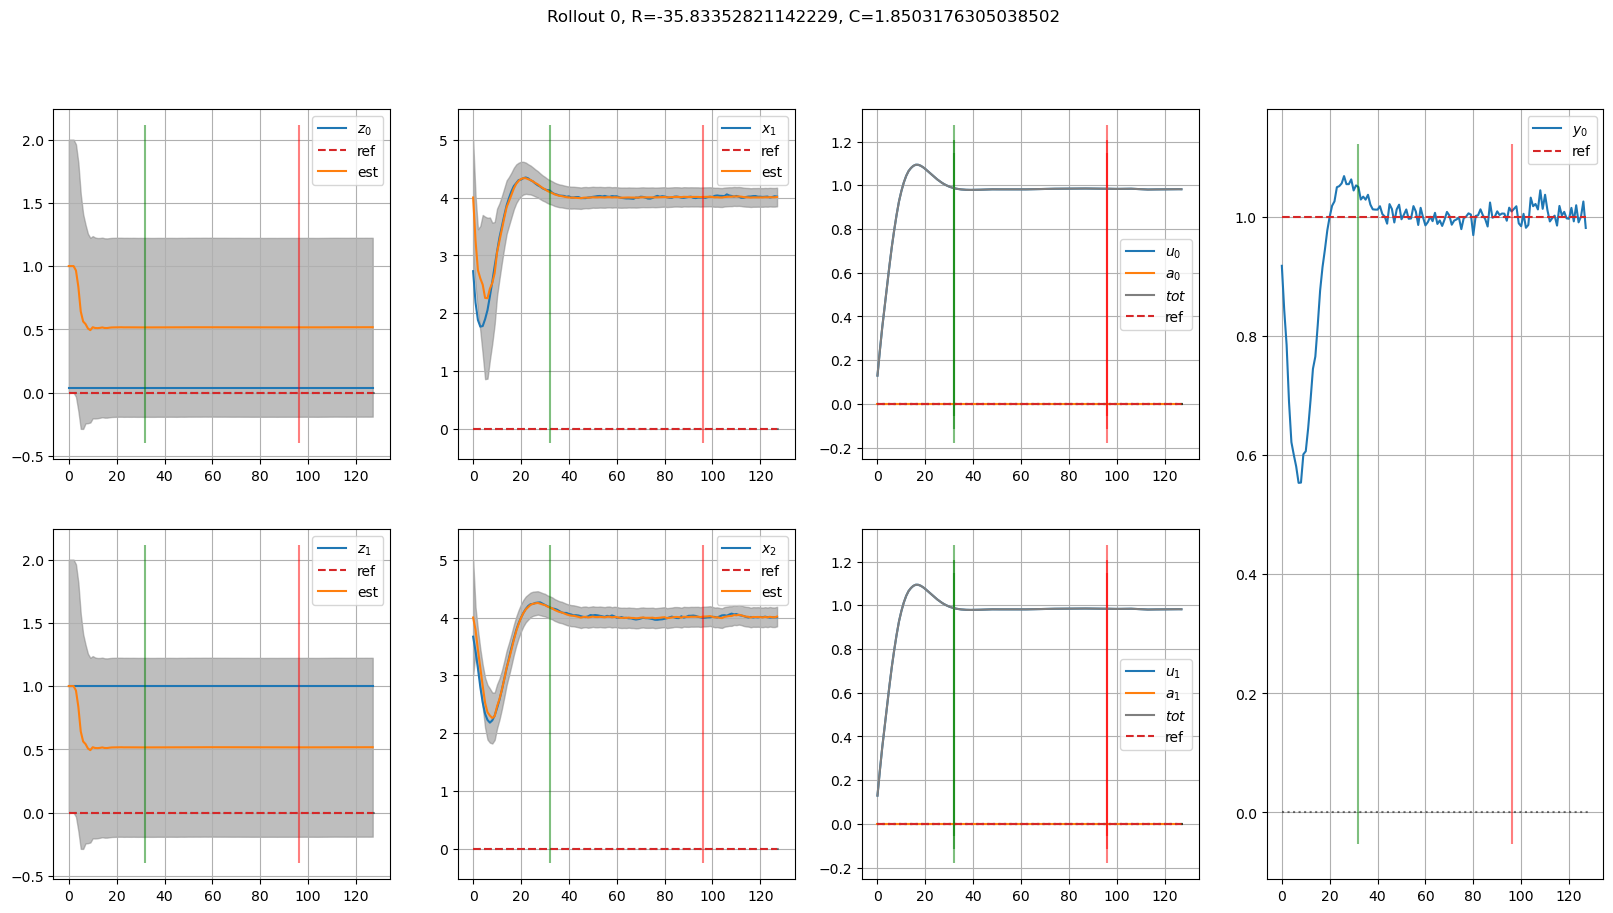

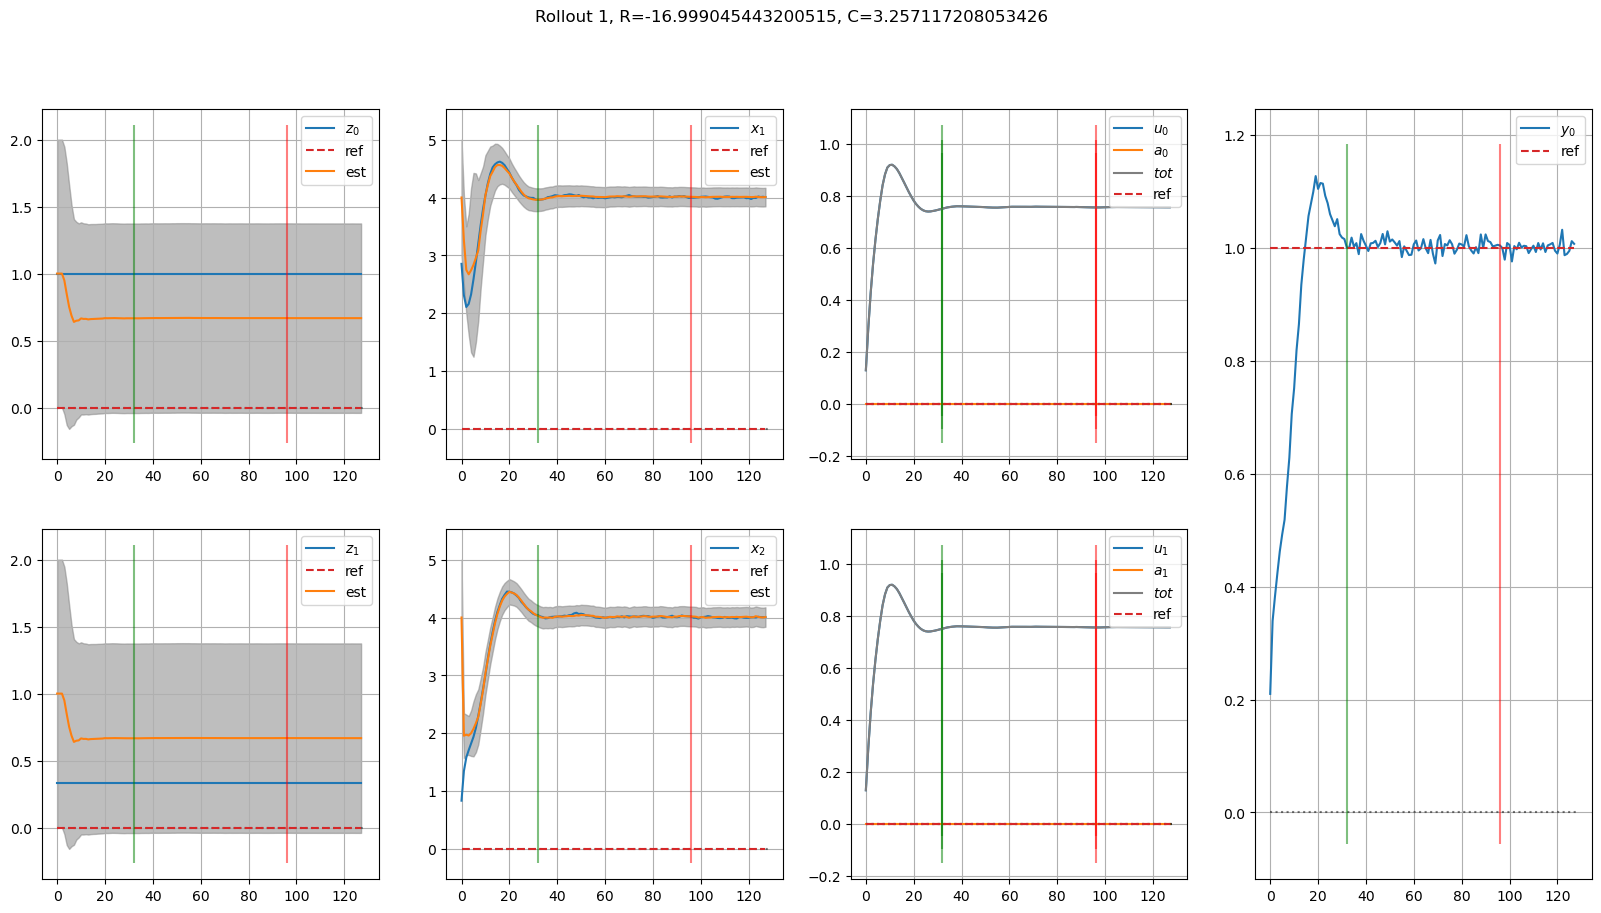

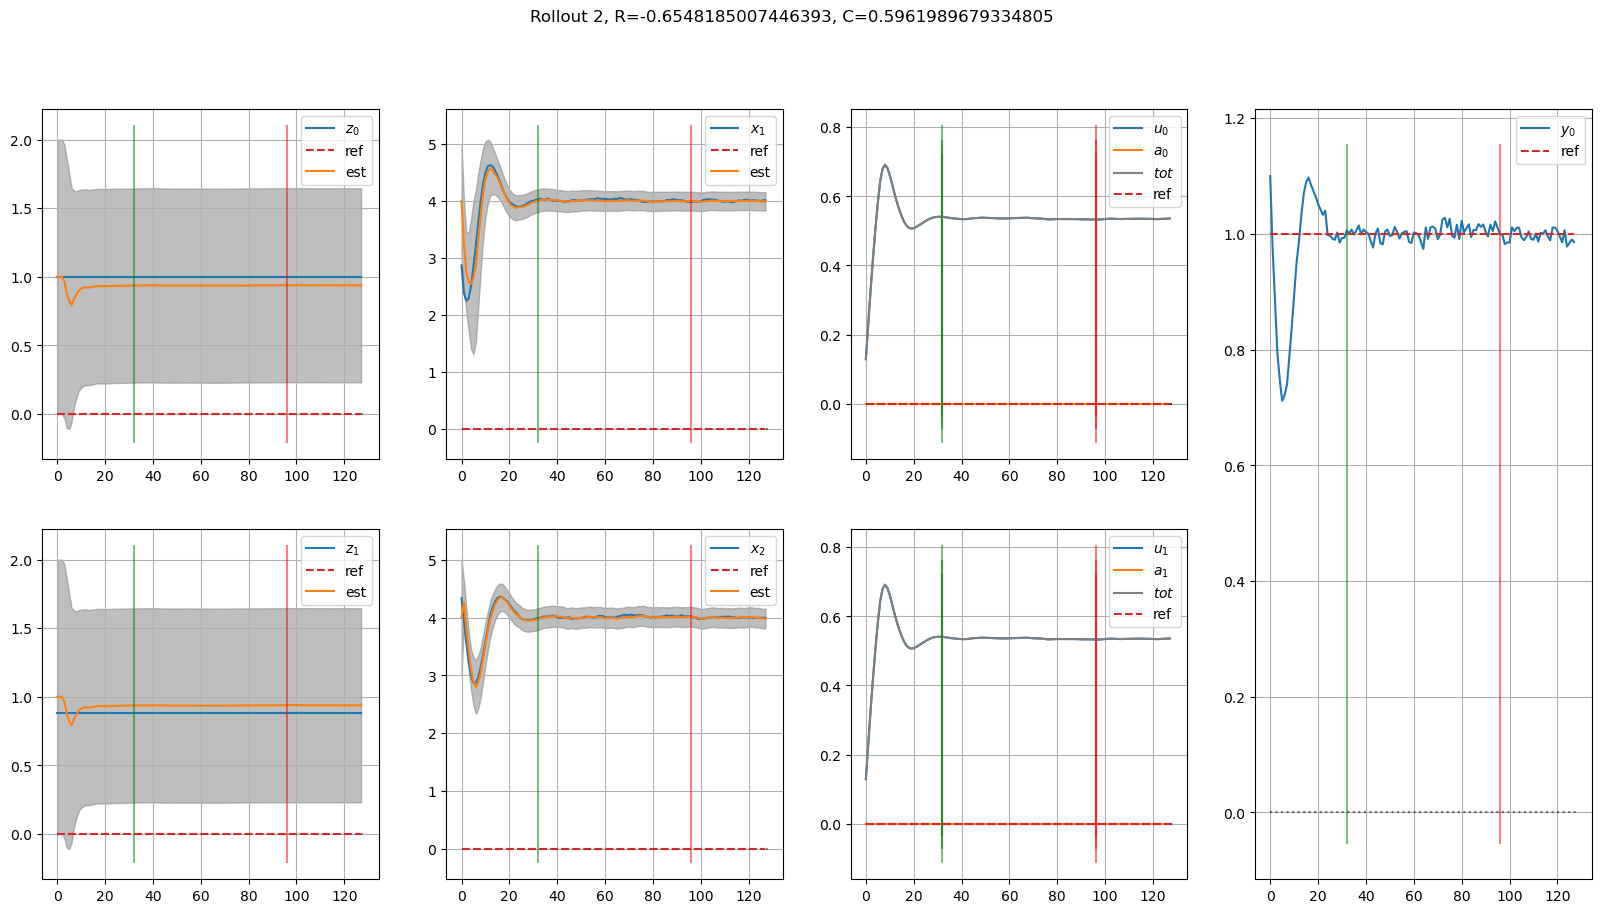

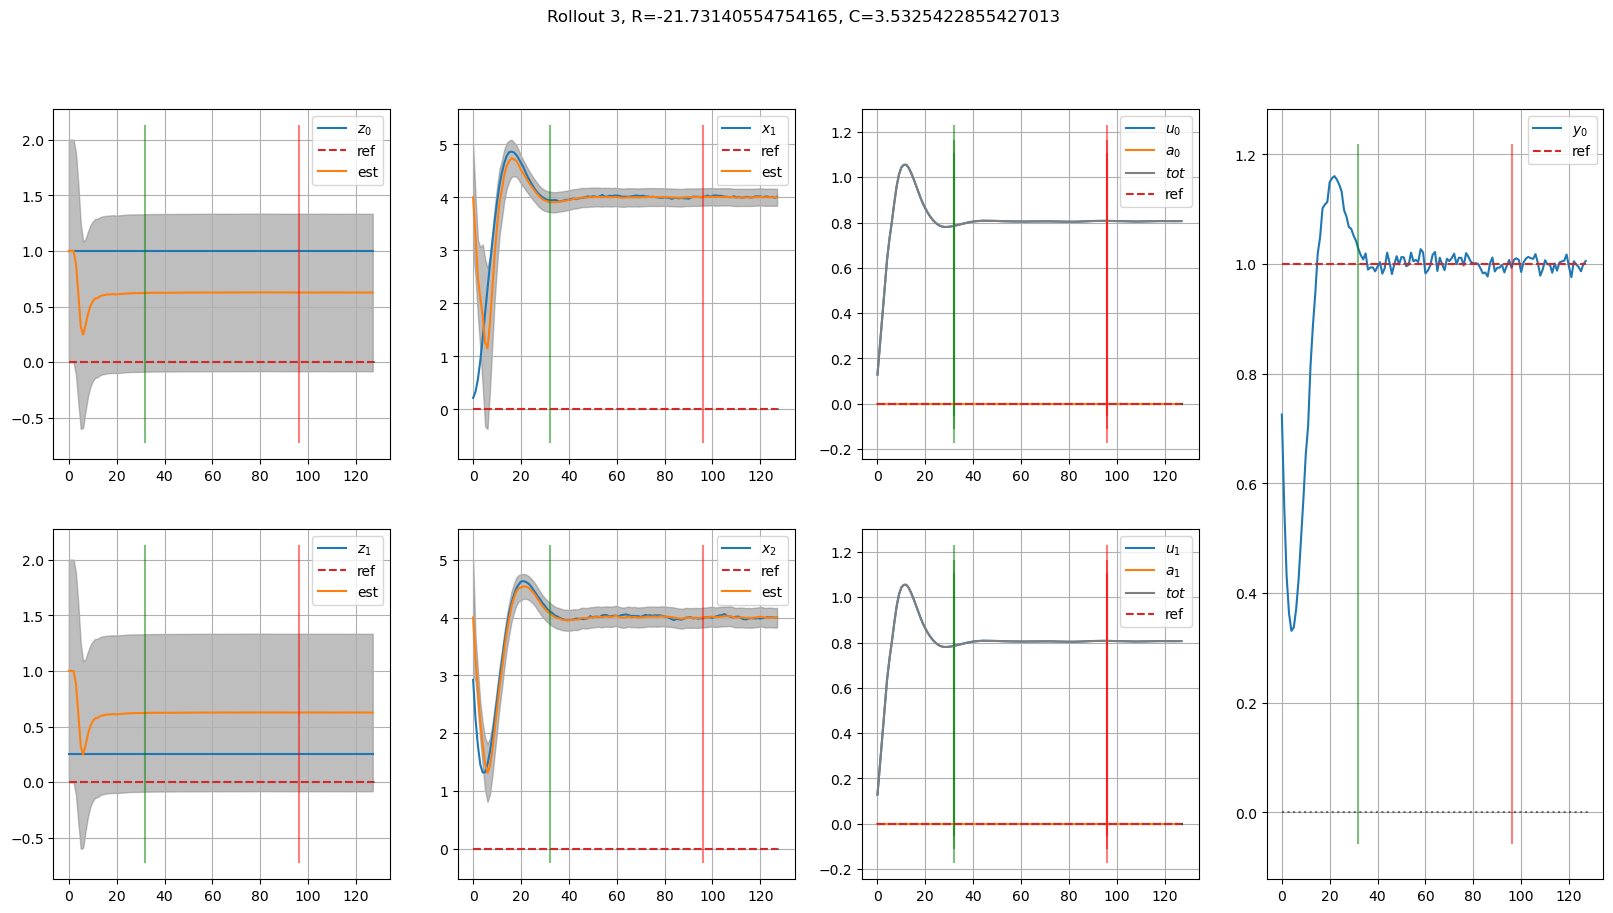

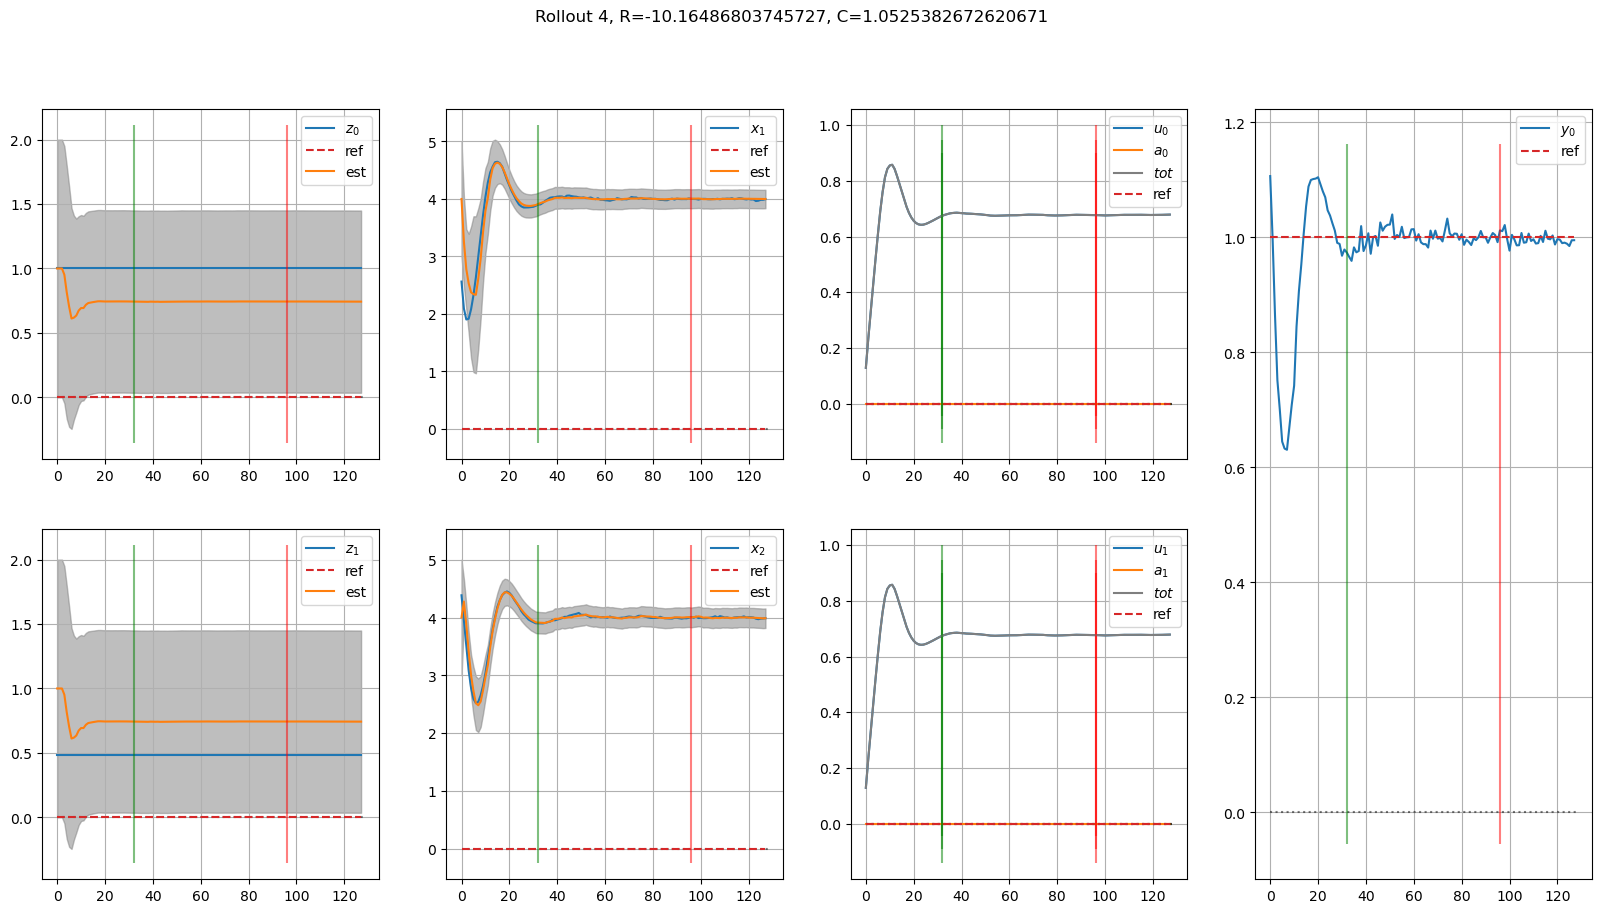

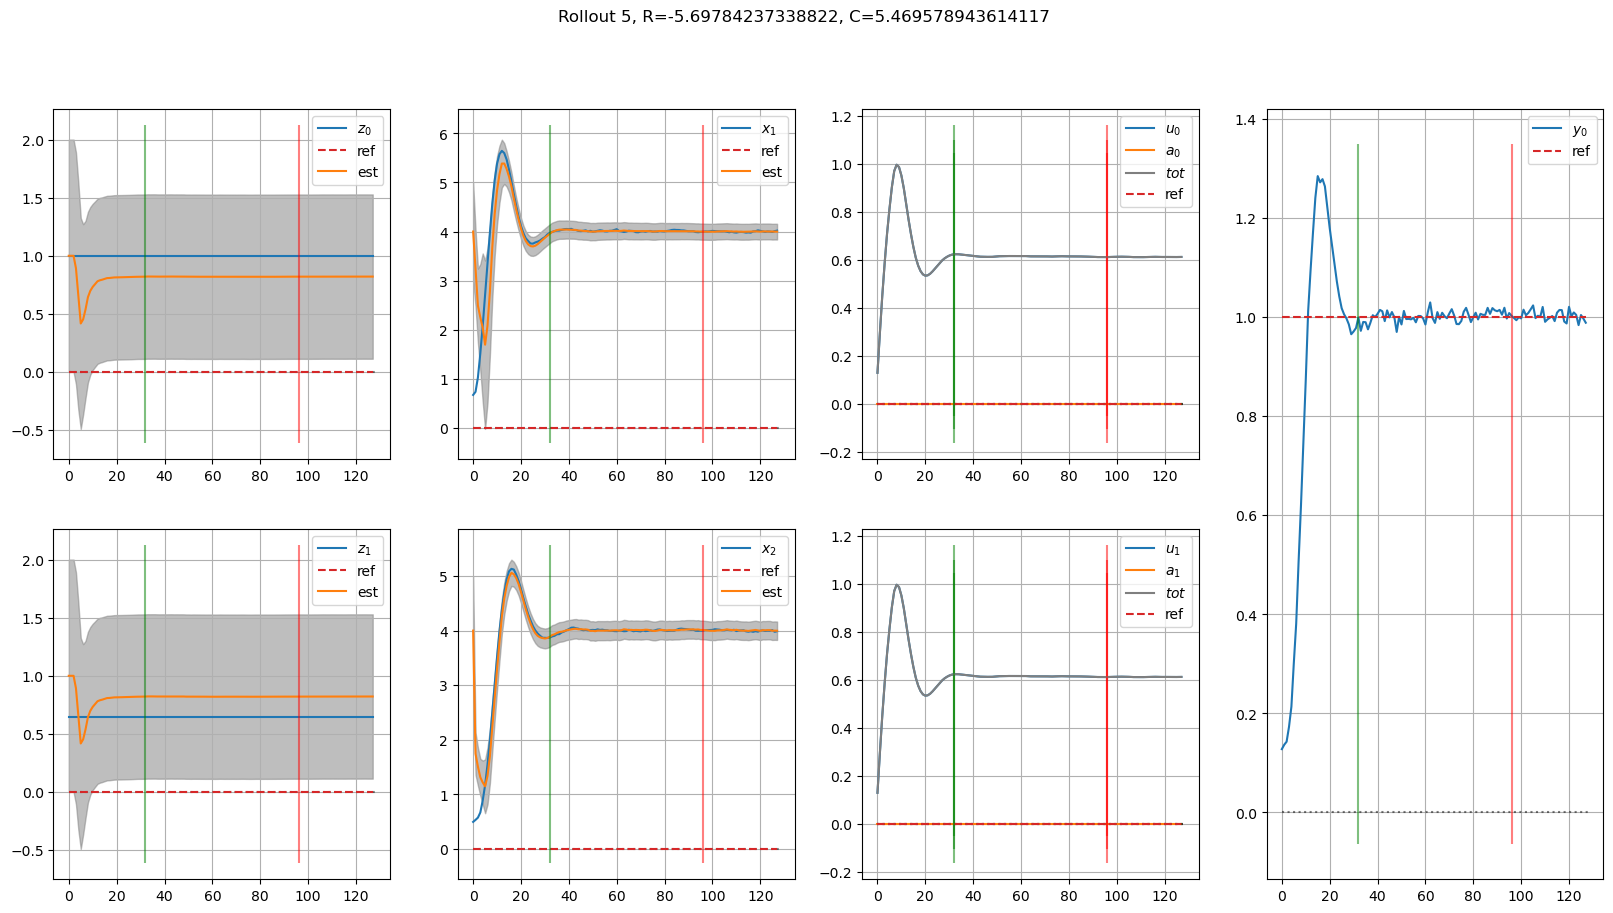

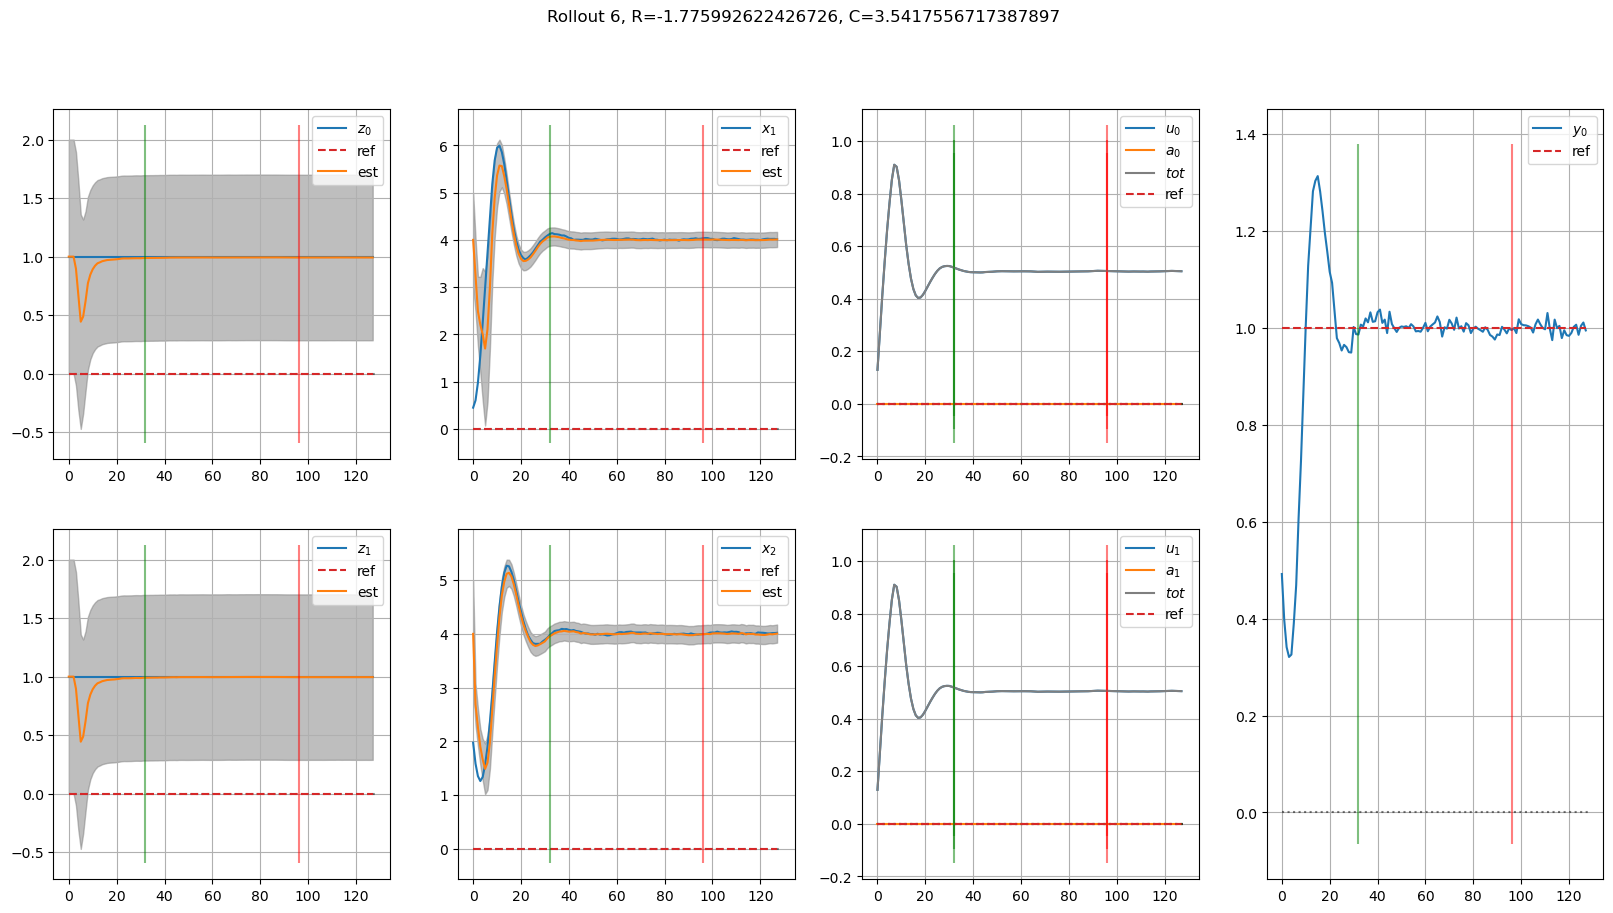

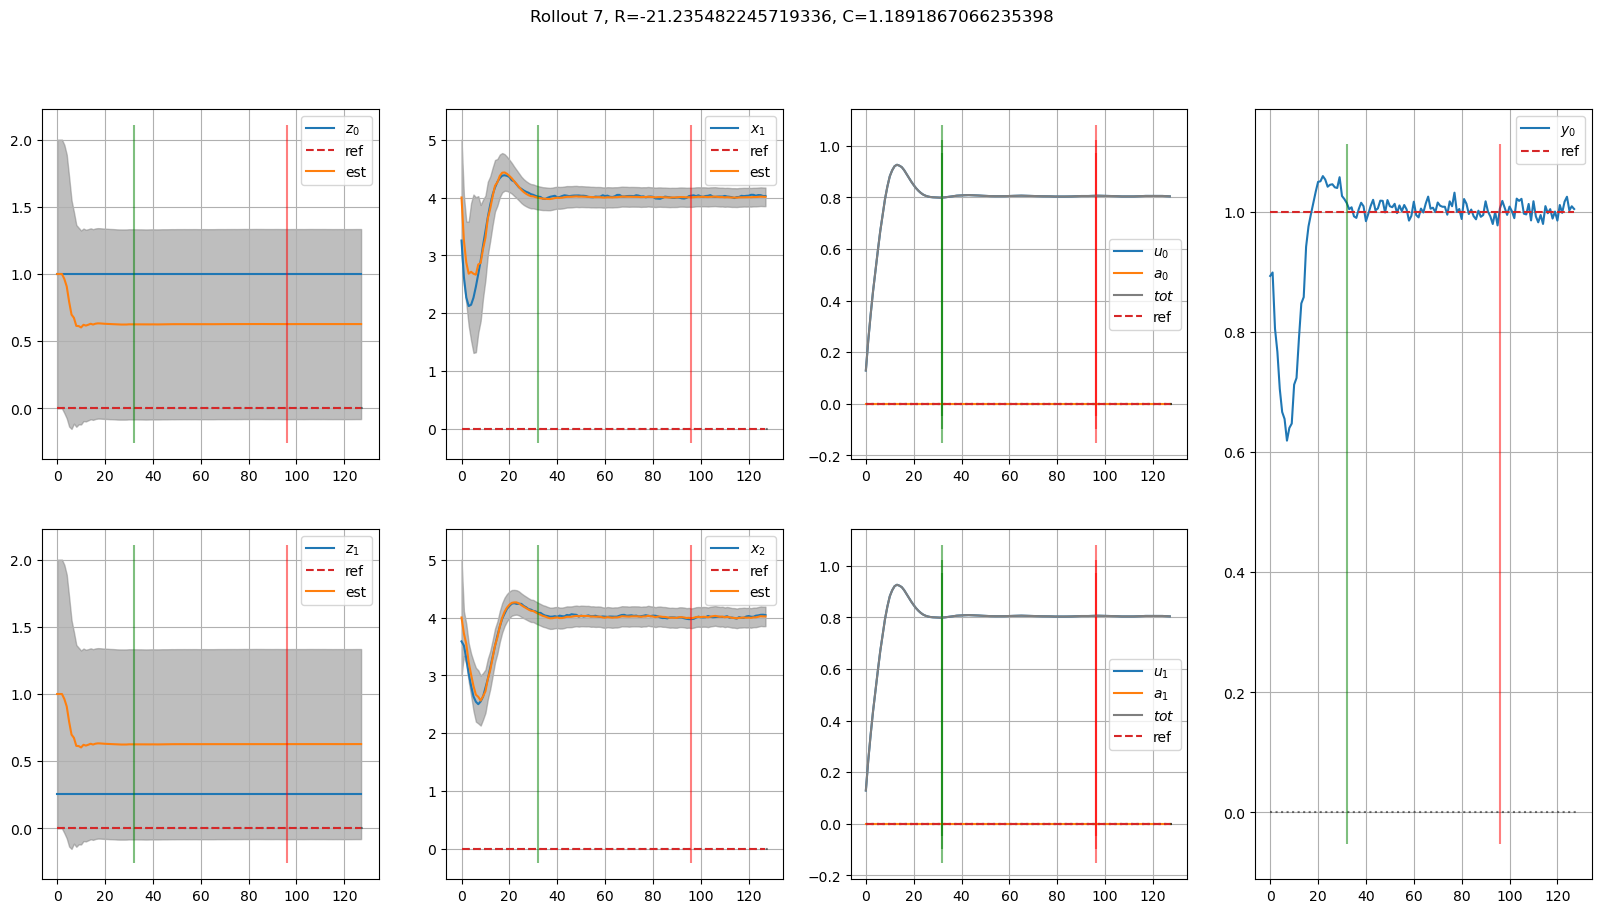

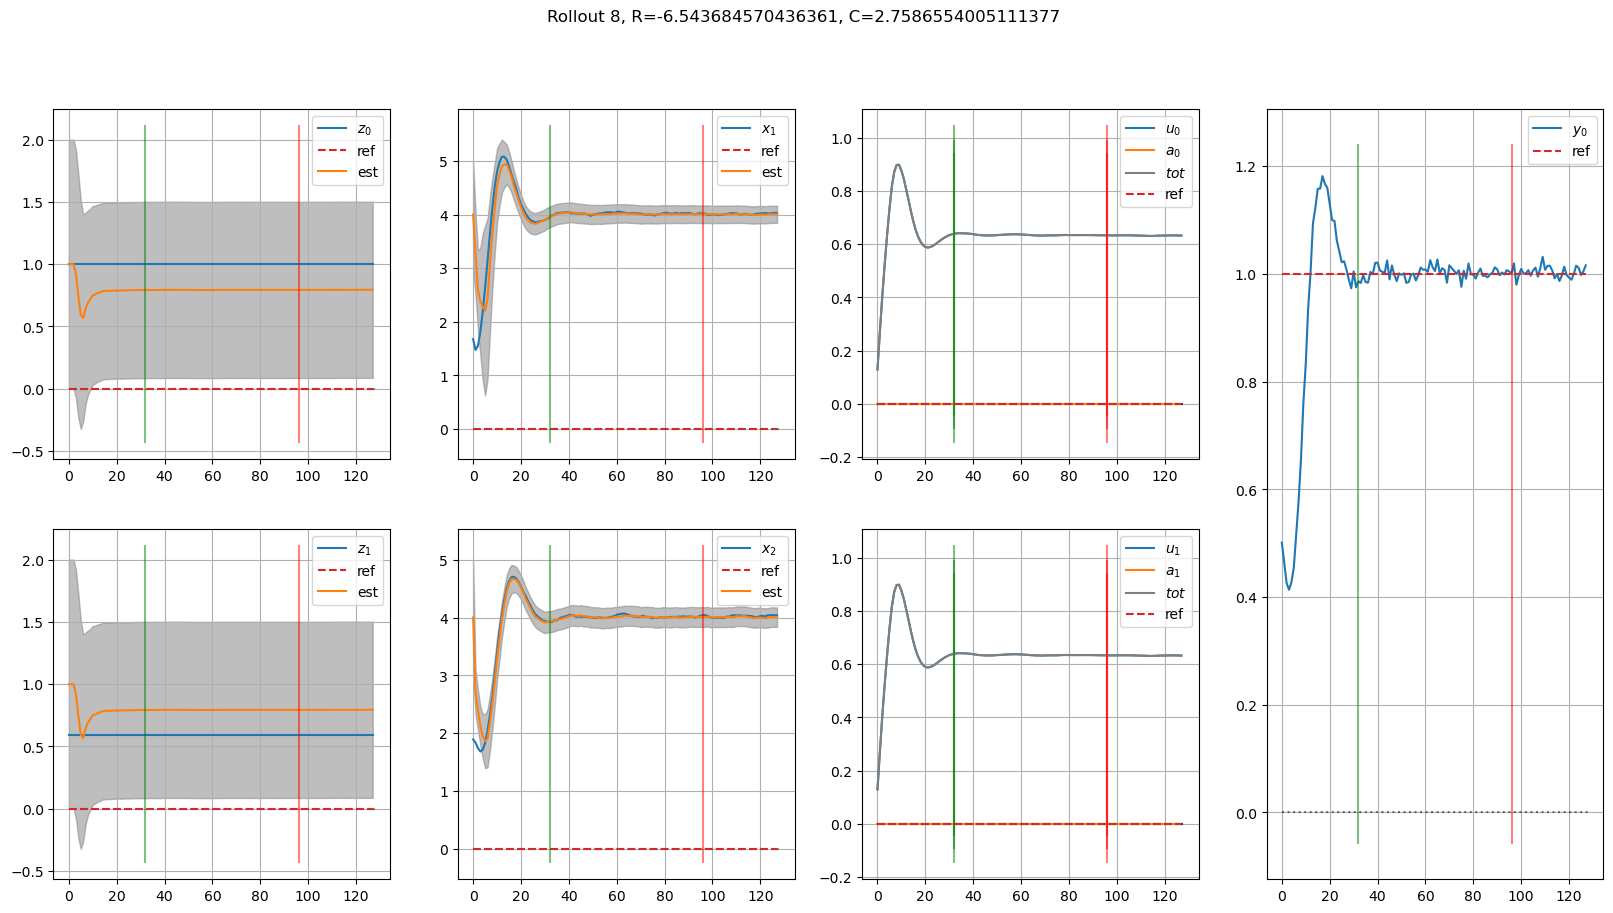

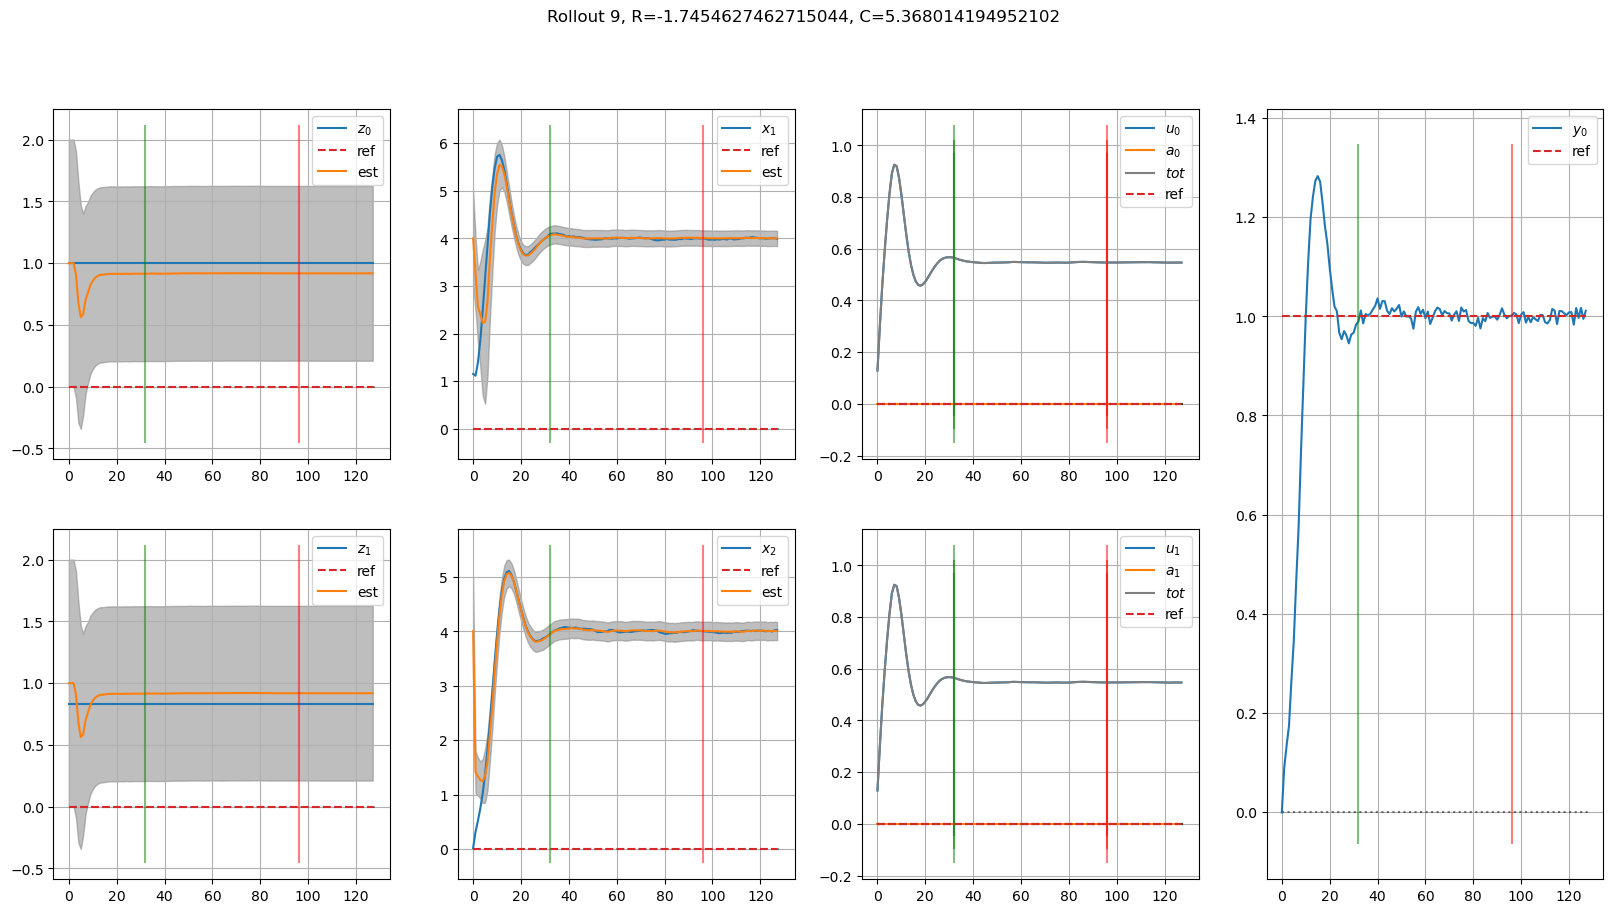

In [4]:
for i in range(10):
    rollout, out = get_rollout(env, None, 128)    
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    fig = env.render(out, title=f"Rollout {i}, R={R}, C={C}")

# Untrained policy

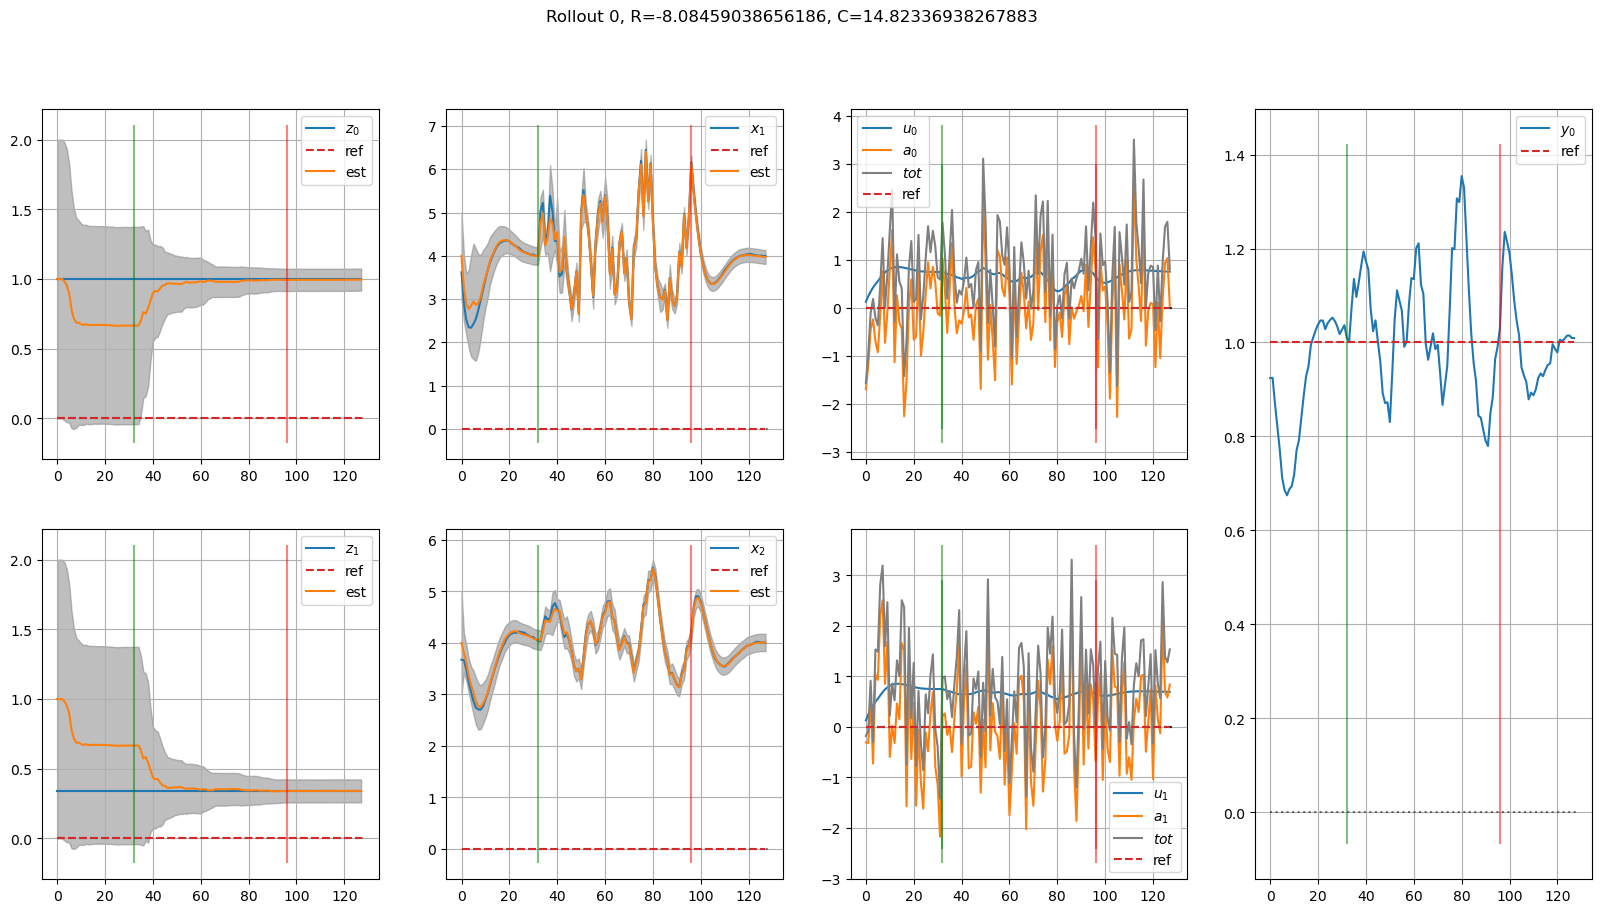

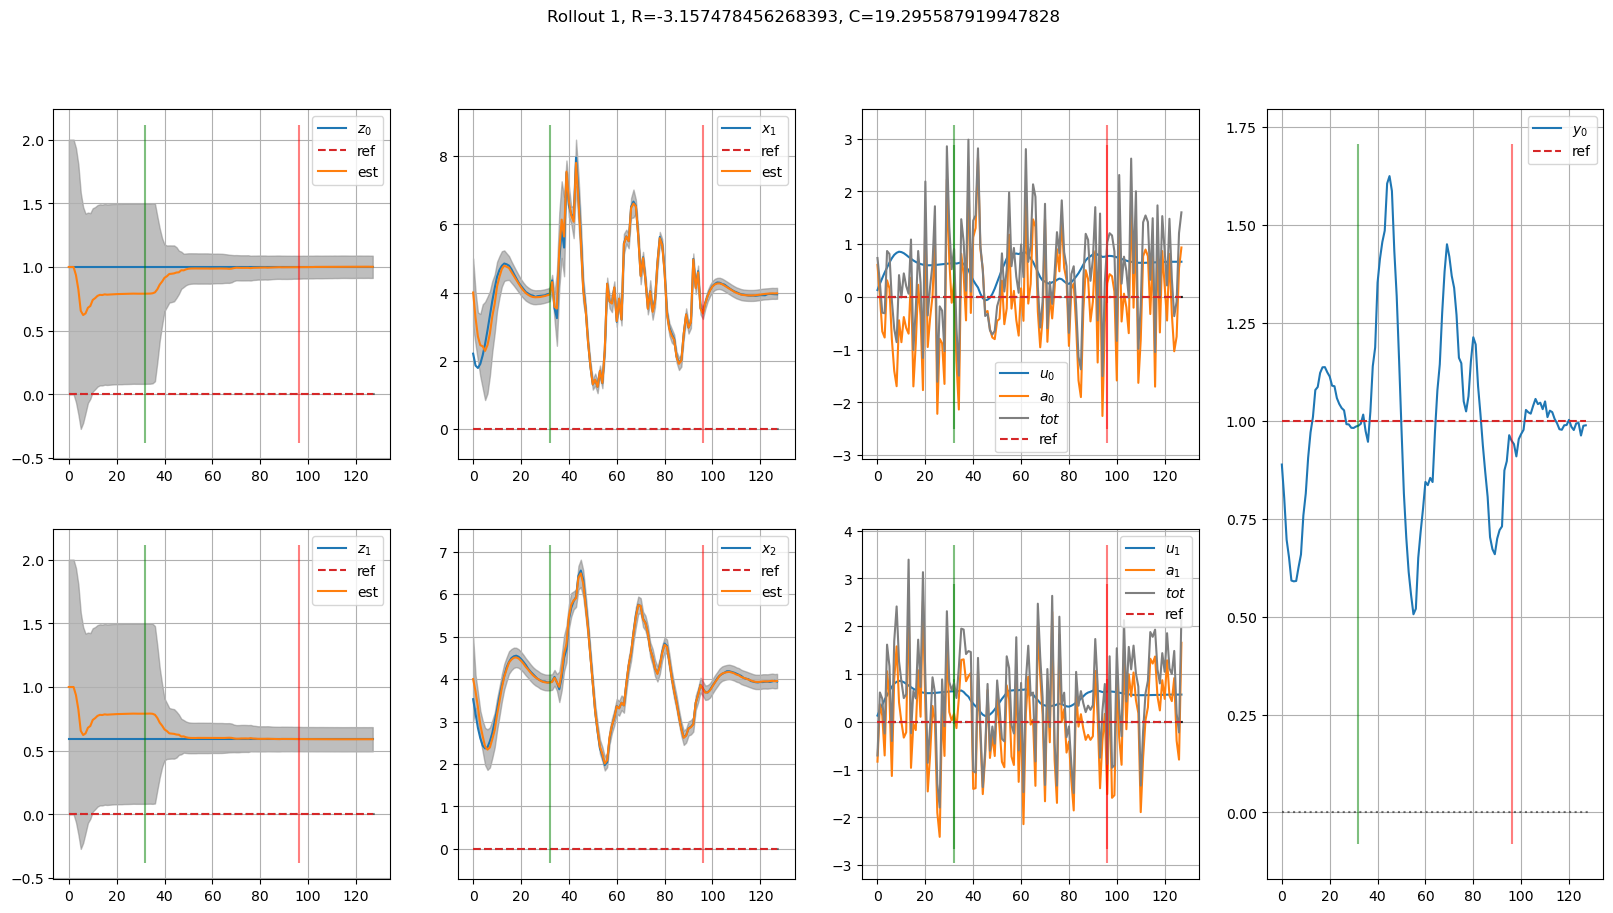

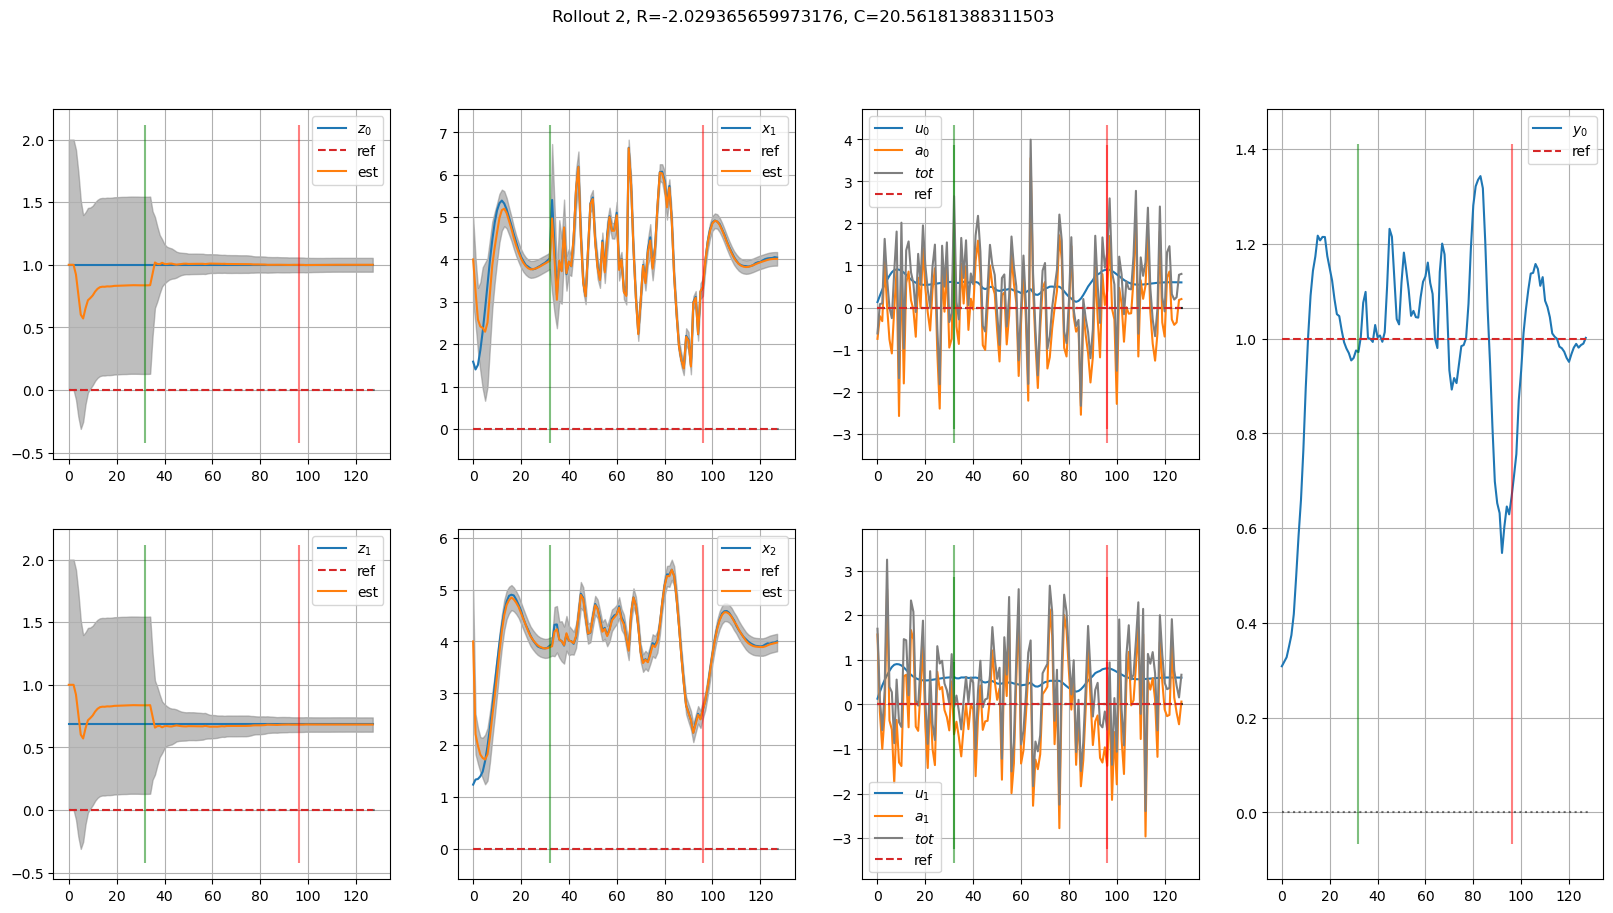

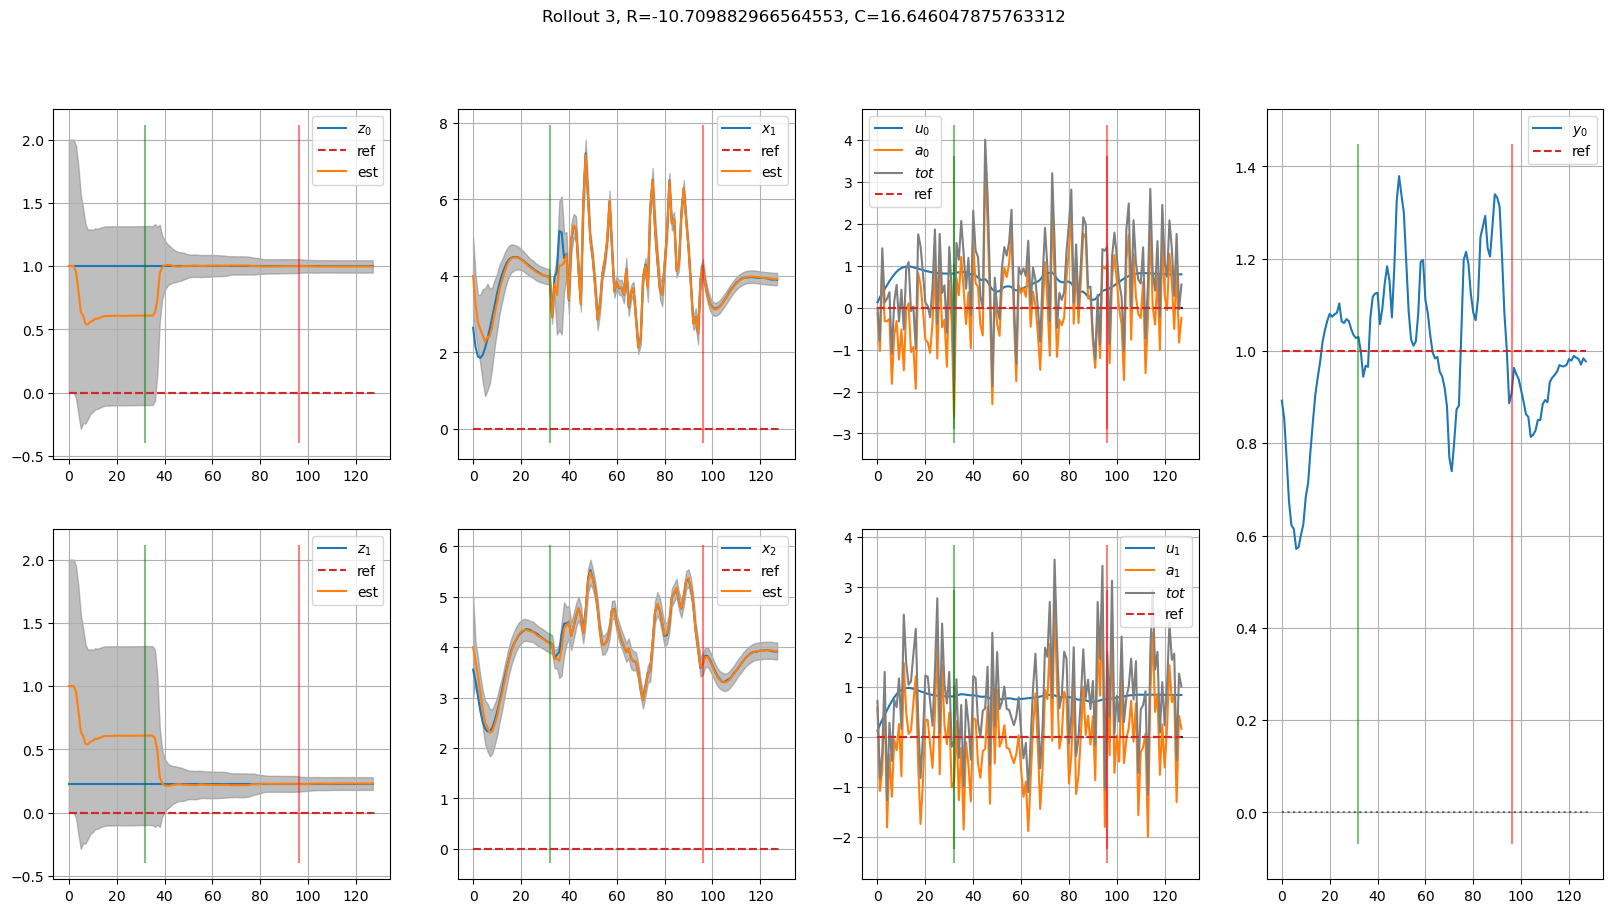

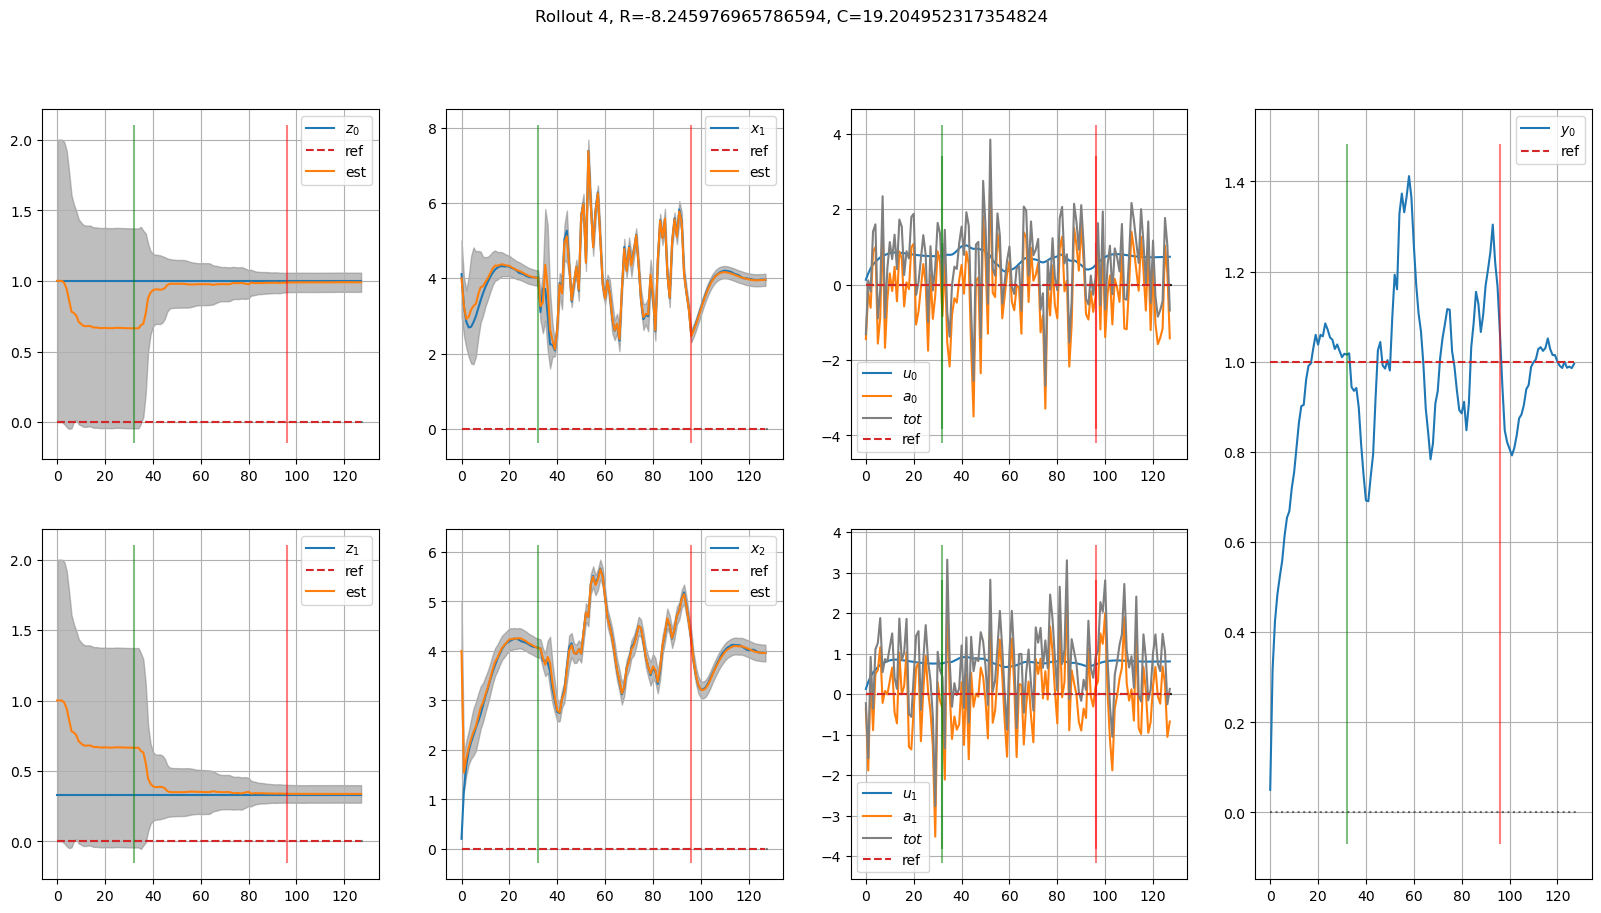

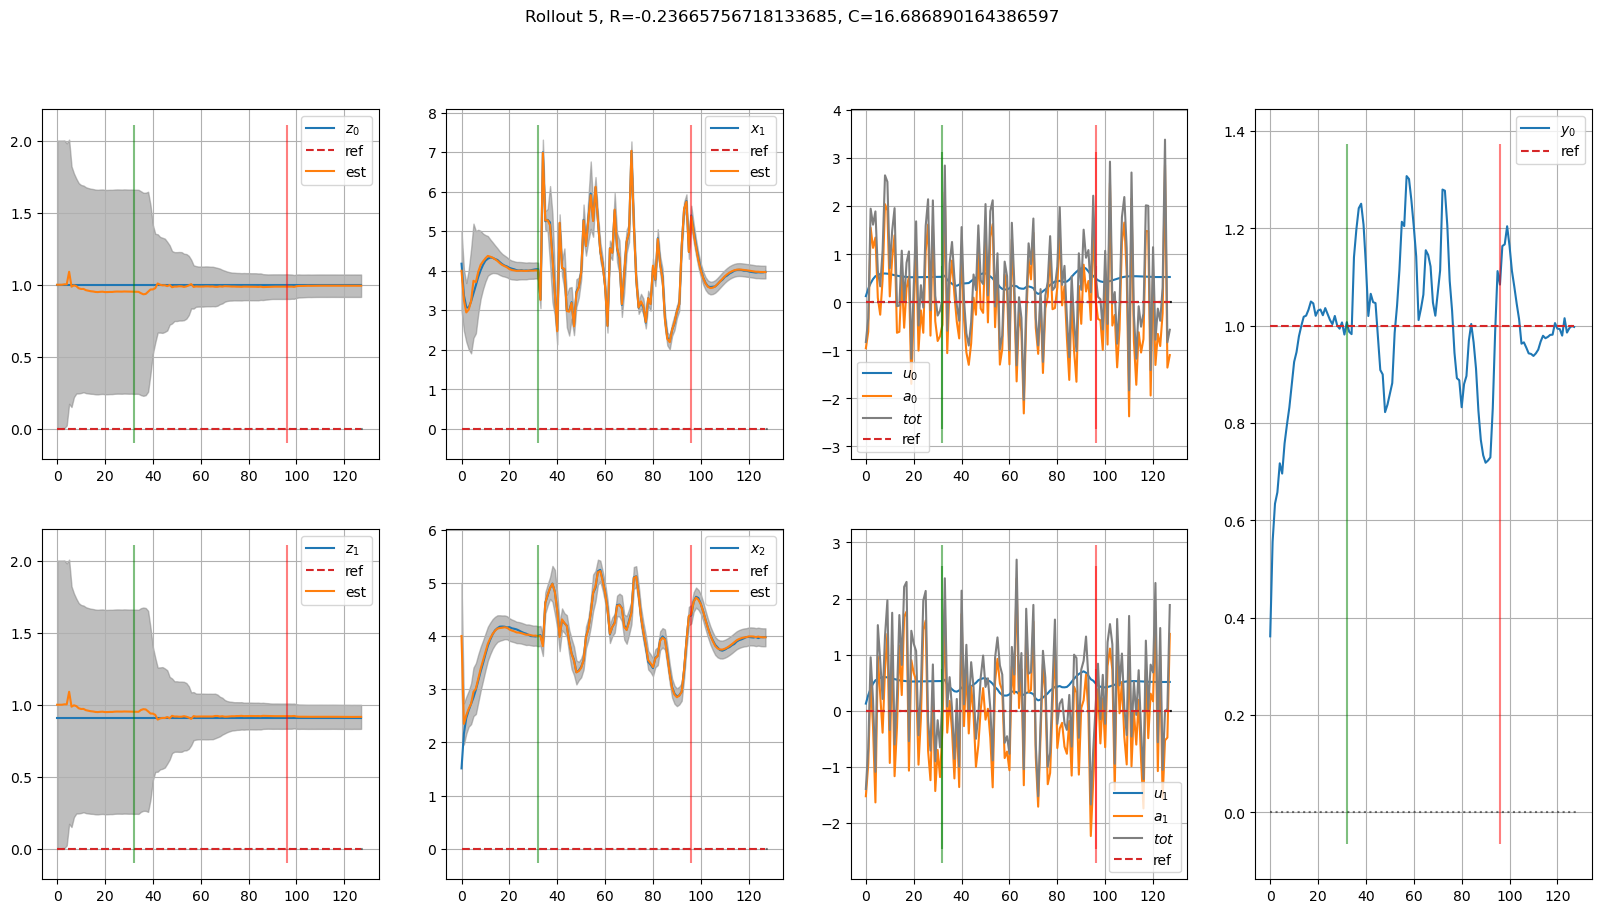

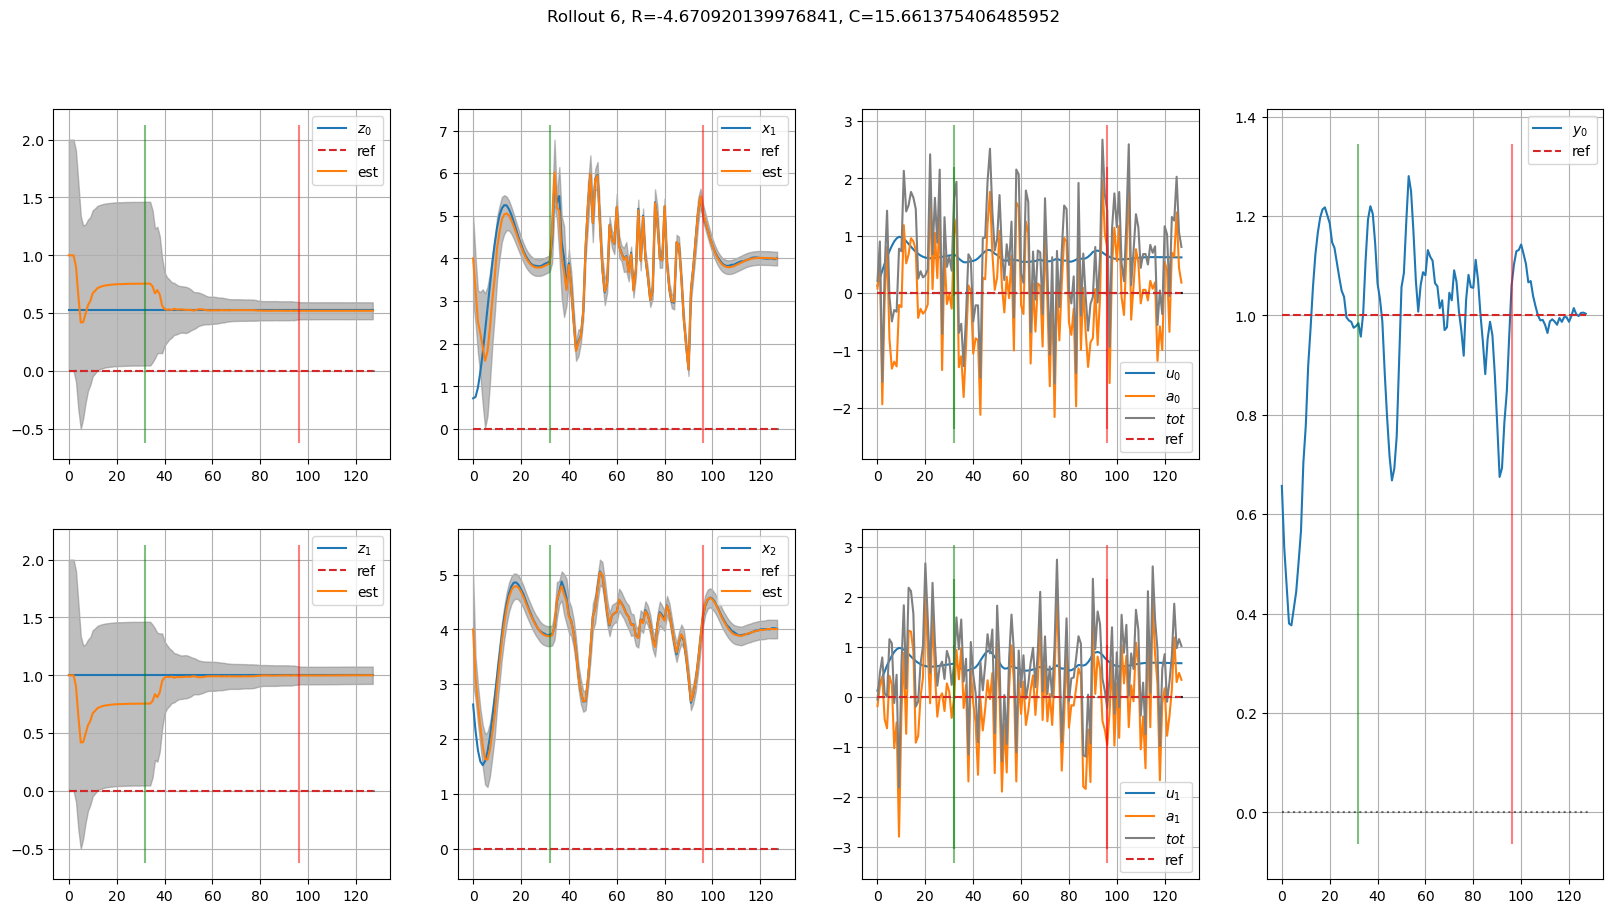

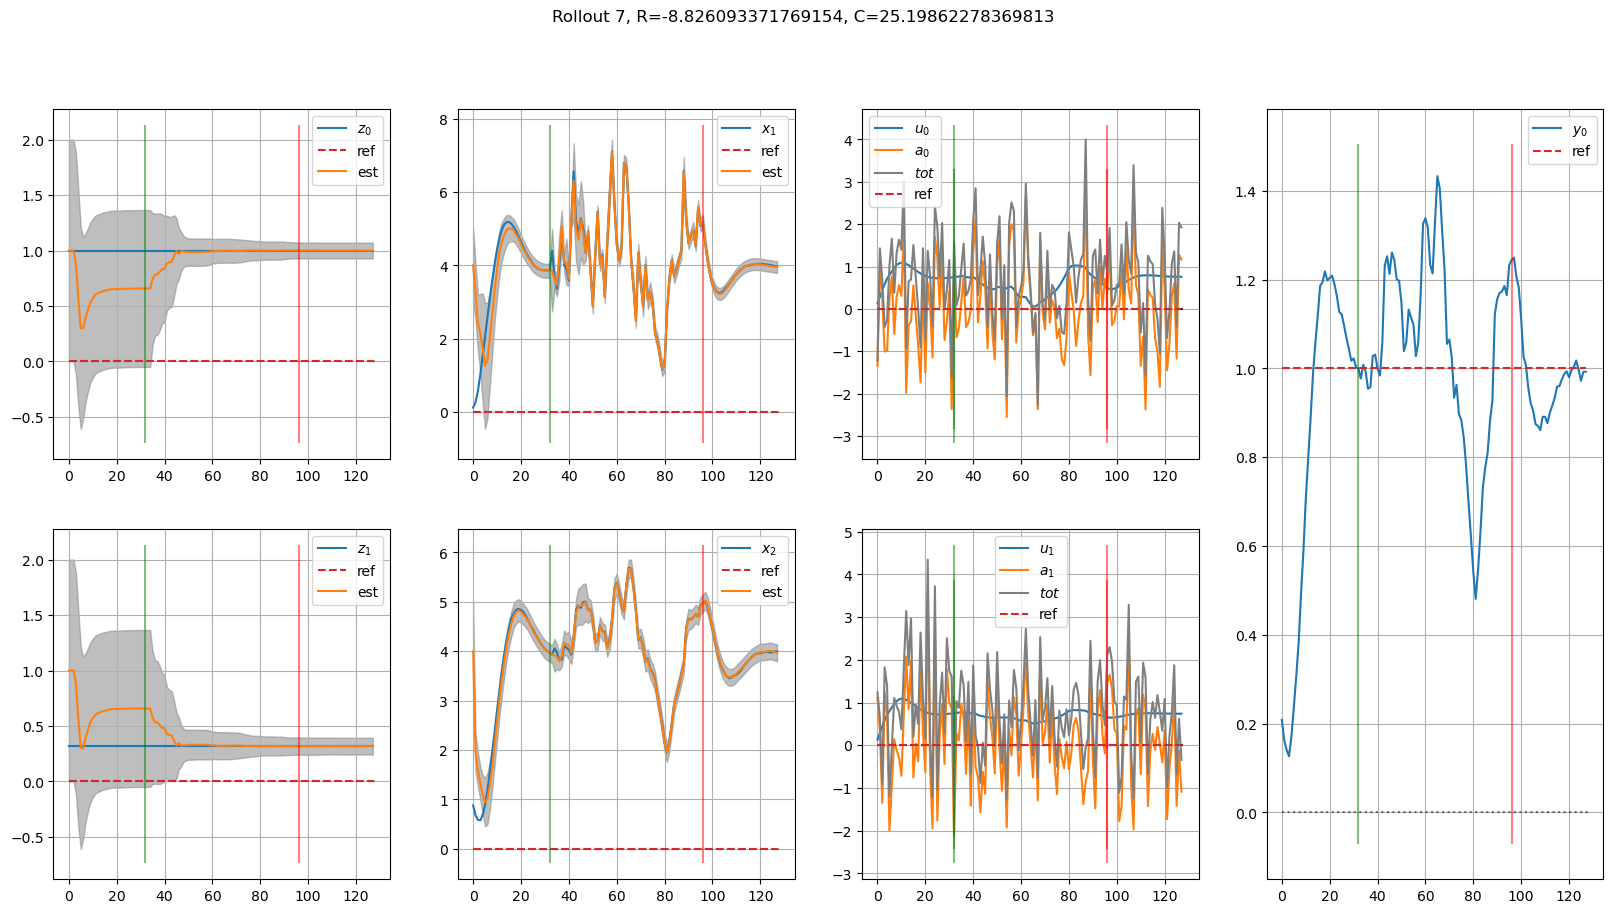

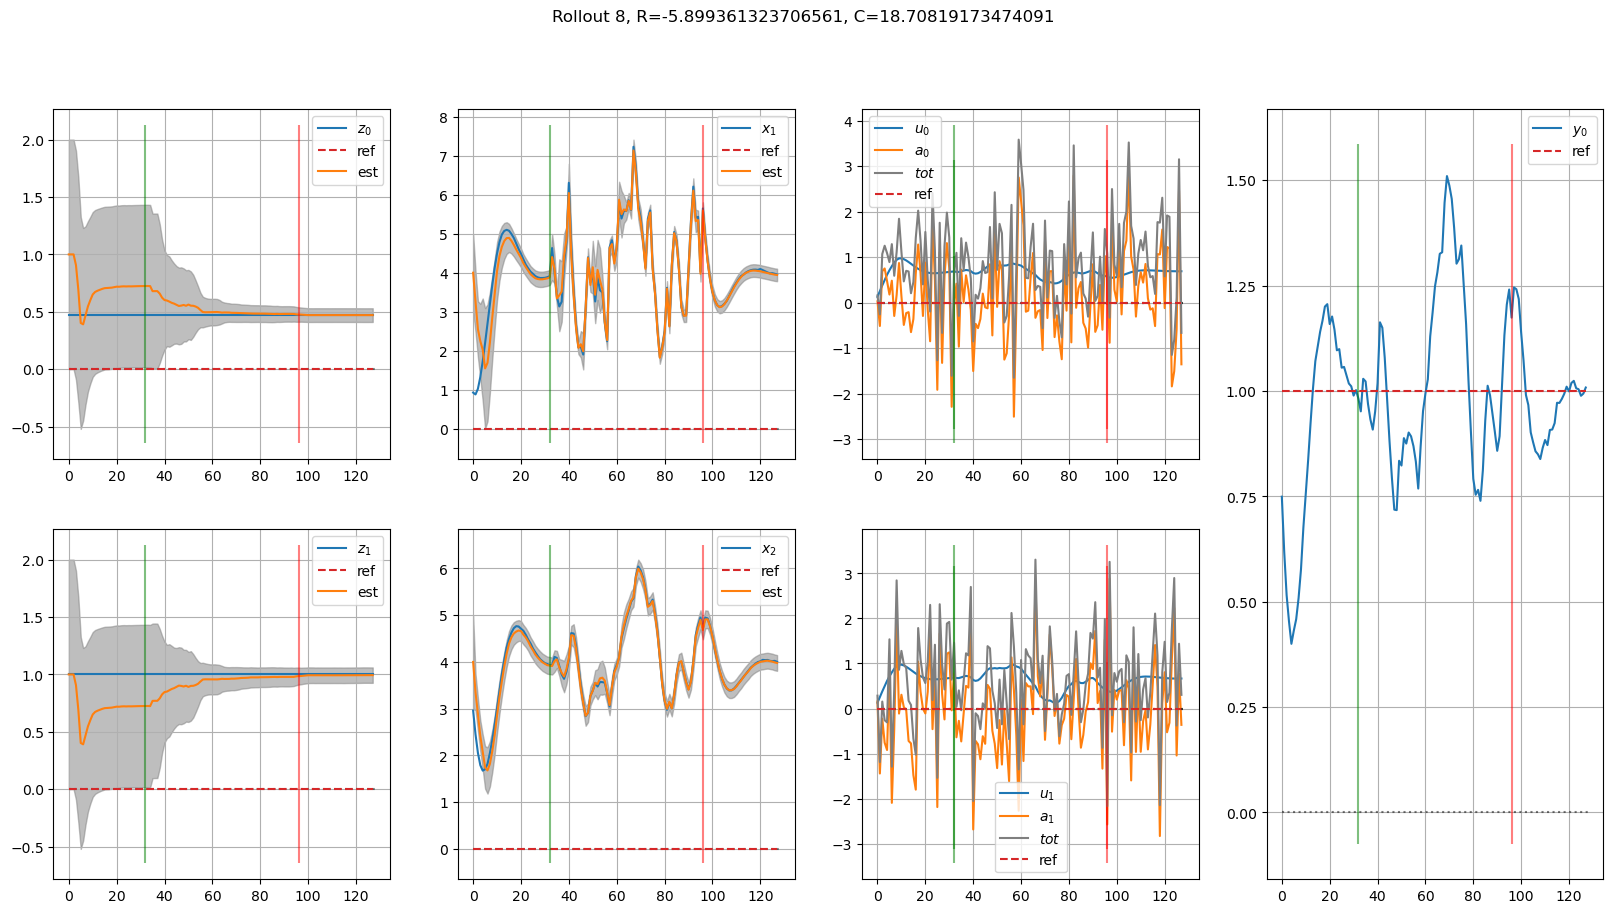

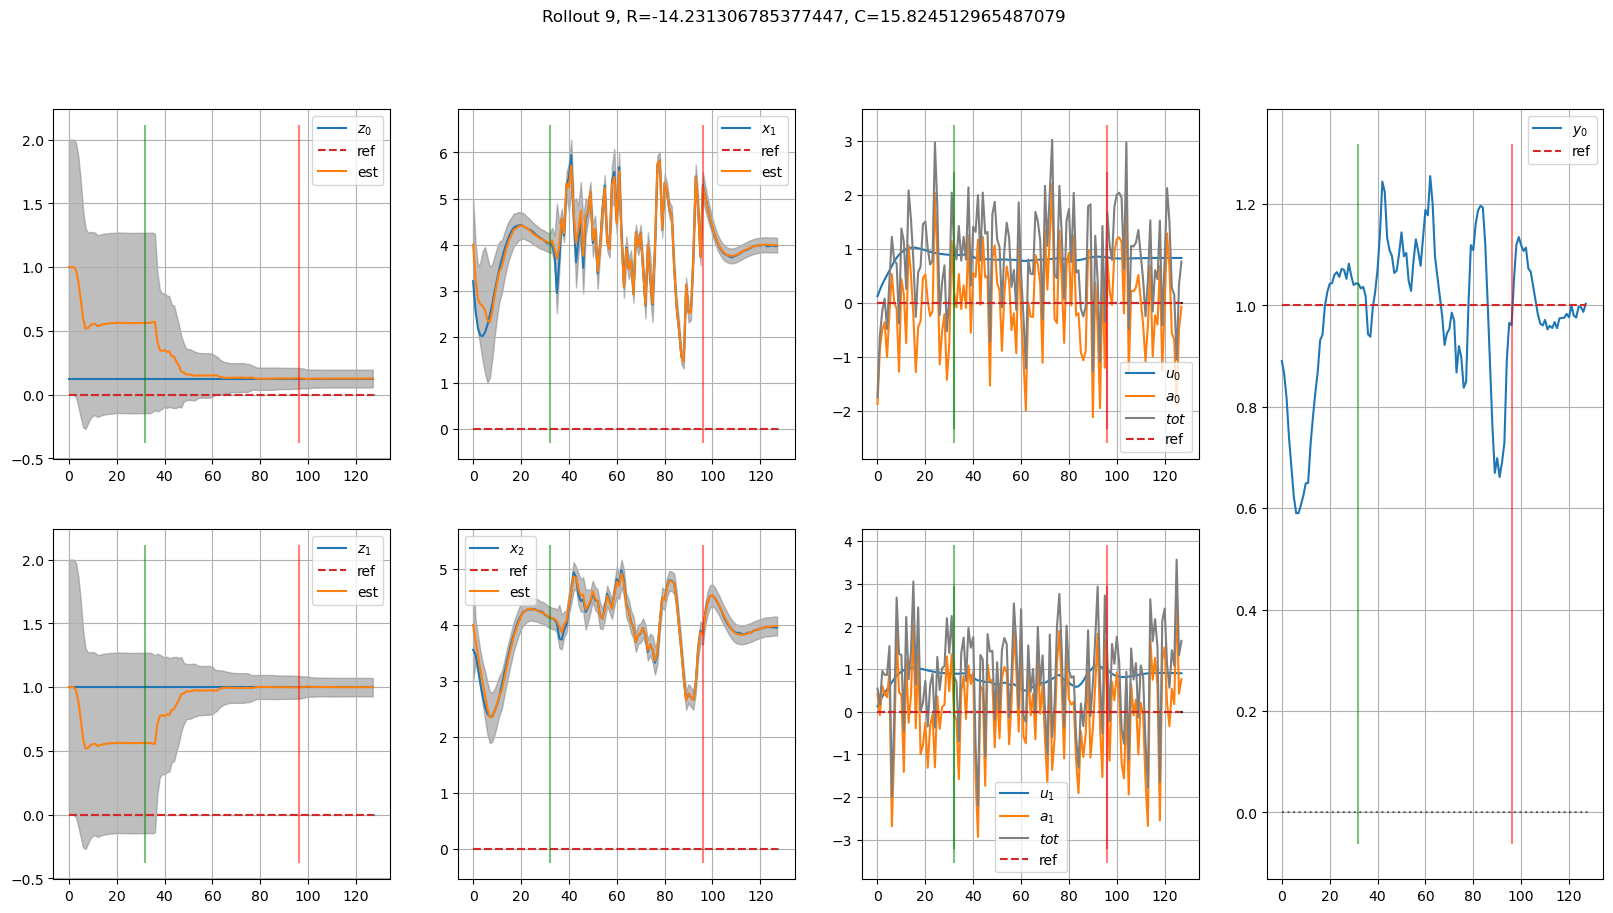

In [5]:
for i in range(10):
    rollout, out = get_rollout(env, trainer.policy, 128)    
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    fig = env.render(out, title=f"Rollout {i}, R={R}, C={C}")

# Train

In [ ]:
logger = trainer.train(epochs=1000, episode_length=128)
nnx.display(trainer.policy)

  0%|          | 0/1000 [00:00<?, ?it/s]

 37%|███▋      | 371/1000 [01:41<02:46,  3.77it/s, V=-7.49, Vc=3.41, cost=0.0319, reward=-.0735]

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20,10), dpi=600)
plt.subplot(2, 2, 1)
plt.plot(logger["loss_pi"], label="loss_pi")
plt.plot(logger["loss_cpi"], label="loss_cpi")
plt.legend()
plt.grid()
plt.subplot(2, 2, 3)
plt.semilogy(logger["loss_vf"], label="loss_vf")
plt.semilogy(logger["loss_cvf"], label="loss_cvf")
plt.legend()
plt.grid()
batch_returns = jax.vmap(jax.vmap(lambda x: get_returns(x, trainer.discount)[0]))
plt.subplot(2, 2, 2)
r = batch_returns(logger["reward"])
V = logger["V"][:, :, 0]
plt.semilogy(r.mean(-1), label="reward")
plt.fill_between(range(len(r)), r.min(-1), r.max(-1), alpha=0.2)
plt.semilogy(V.mean(axis=-1), label="value")
plt.fill_between(range(len(V)), V.min(axis=-1), V.max(axis=-1), alpha=0.2)
plt.legend()
plt.grid()
plt.subplot(2, 2, 4)
c = batch_returns(logger["cost"])
C = logger["Vc"][:, :, 0]
plt.semilogy(c.mean(-1), label="cost return")
plt.fill_between(range(len(r)), c.min(-1), c.max(-1), alpha=0.2)
plt.semilogy(C.mean(axis=-1), label="cost value fn")
plt.fill_between(range(len(C)), C.min(axis=-1), C.max(axis=-1), alpha=0.2)
plt.hlines(trainer.max_cost, 0, len(c), "r", "--", label="max cost")
plt.legend()
plt.grid()
plt.tight_layout()
fig.show()

# Trained Policy

In [ ]:
for i in range(10):
    rollout, out = get_rollout(env, trainer.policy, 128)
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    fig = env.render(out, title=f"Rollout {i}, R={R}, C={C}")
    fig.show()

# Trained Deterministic

In [ ]:
trainer.policy.std.value *= 1e-20
for i in range(10):
    rollout, out = get_rollout(env, trainer.policy, 128)
    R = get_returns(rollout.r, trainer.discount)[0]
    C = get_returns(rollout.c, trainer.discount)[0]
    fig = env.render(out, title=f"Rollout {i}, R={R}, C={C}")
    fig.show()